# ⏱️ Statistical models: ACF/PACF, SARIMA 

In [47]:
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid") 
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR,LinearSVR


import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# 📦 Get data 
We load the Australia electricity dataset, parse the `datetime` index, and create a *short window* subset.  
A compact window makes patterns easy to see before we scale up.

            electricity
datetime               
1956-03-01         3923
1956-06-01         4436
1956-09-01         4806
1956-12-01         4418
1957-03-01         4339


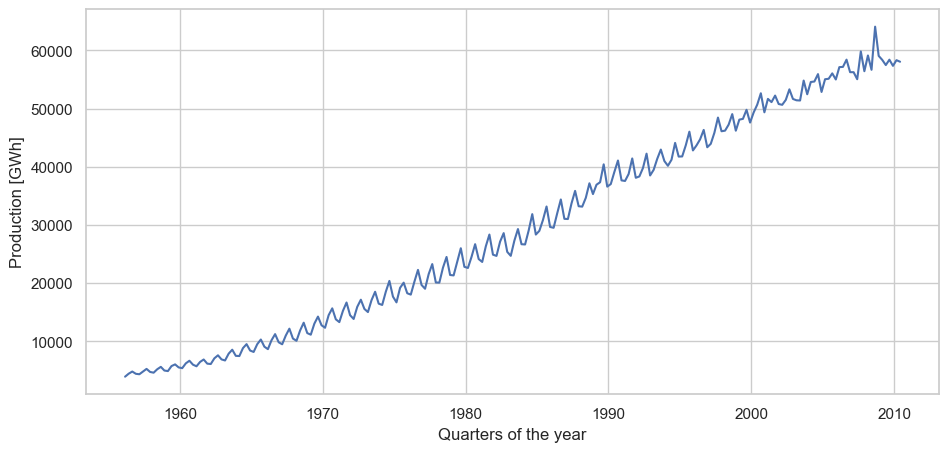

In [48]:
df = pd.read_excel('data/Australia_electricty_data.xlsx')
df = df.rename(columns={"Unnamed: 0":"datetime", "Electricity [GWh]": "electricity"})
df.set_index('datetime',inplace=True)

print(df.head(5))

#plt.style.use("seaborn-whitegrid")
plt.figure(figsize=(11,5))
p = sns.lineplot(data= df);
p.set_ylabel("Production [GWh]");
p.set_xlabel("Quarters of the year");

plt.legend('', frameon=False);
plt.show()

In [7]:
dfs = df.loc['1956-03-01':'1968-12-01']

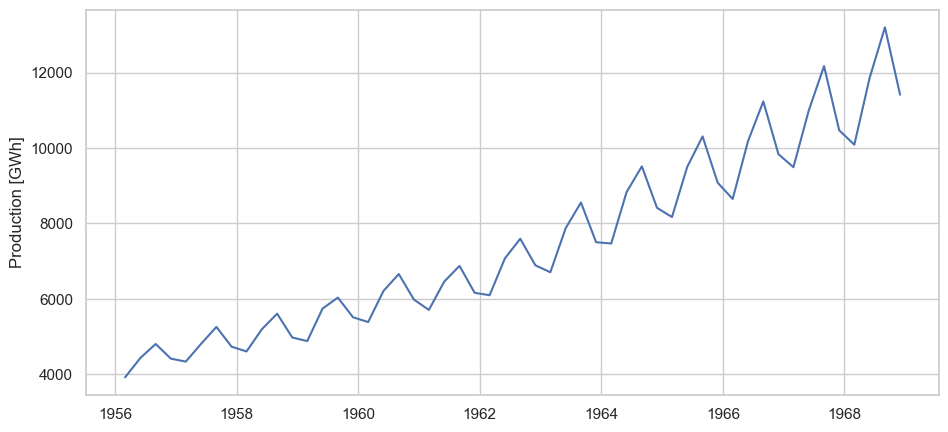

In [49]:
plt.figure(figsize=(11, 5))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.plot(dfs['electricity'])
plt.ylabel('Production [GWh]')
plt.show()

# 🧪 Stationarity check (ADF)  

## 🤔 What is “stationary”?

A time series is **stationary** if its behavior doesn’t drift over time — the average level and the “wiggliness” (variance) don’t keep changing.
Think: *no creeping trend, no growing swings.*

## 🧠 What does ADF test do?

**ADF (Augmented Dickey–Fuller)** checks if your series acts like a **random walk** (non-stationary).

* **Null (H₀):** series is **non-stationary** (has a unit root).
* **If p-value is small:** we **reject H₀** → the series looks **stationary** (under the way you tested it).

## 🔍 Why do we care?

Most statistical models (ACF/PACF logic, ARIMA pieces) work best on **stationary** data.
If your series isn’t stationary, you usually **difference** it (and for quarterly/monthly data, also **seasonal-difference**).

## 👣 Quick steps you’ll follow

1. Plot your series — do you see a trend/seasonality?
2. (Optional but common) Difference it:

   * **First difference:** `y.diff()`
   * **Seasonal difference (quarterly):** `y.diff(4)`
   * Often: **seasonal + first:** `y.diff(4).diff()`
3. Run **ADF** on the series you plan to model.
4. Look at **p-value** and **ADF statistic**.

## 📖 How to read the result

* **p < 0.05** → good evidence of **stationarity** ✅
* **p ≥ 0.05** → likely **non-stationary** ❌ (try differencing and test again)

You’ll also see:

* **ADF statistic** (more negative = stronger stationarity signal)
* **Critical values** (1%, 5%, 10%) to compare with the ADF statistic
* **Lags used** (ADF adds past differences so the test behaves well)


## ✅ Typical outcomes

* After **`diff(4).diff()`**, p gets small → series is ready for ARIMA/SARIMA modeling.
* If p stays large, consider more careful detrending, transformations (e.g., log), or check for structural breaks.


In [41]:

fuller = adfuller(dfs['electricity'])
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 2.233387
p-value: 0.998909
Critical Values:
	1%: -3.578
	5%: -2.925
	10%: -2.601


## 🤔 Interpretation

* The **ADF statistic** is **+2.23** (a positive number), while the critical values are **negative** (e.g., −2.93 at 5%).
* Because **+2.23 is nowhere near (i.e., not less than)** any critical value, and the **p-value ≈ 0.999** is very large, we **cannot reject** the null hypothesis (**H₀: unit root / non-stationary**).
* **Conclusion:** the series in its current form is **non-stationary** ❌.


# 🧩 Decomposition

**Why decompose?**  
Split the series into **Trend**, **Seasonal** (quarterly, period=4), and **Remainder**.  
- Trend: long-run movement  
- Seasonal: repeated intra-year pattern  
- Remainder: short-term noise  
This guides differencing and seasonal model choices.


<Figure size 1500x1000 with 0 Axes>

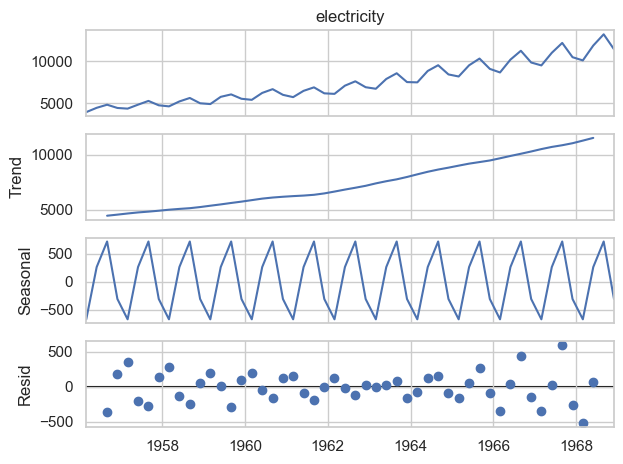

In [50]:
decompose = seasonal_decompose(dfs['electricity'],
                               model='additive', period=4)
plt.figure(figsize=(15,10))
decompose.plot();
plt.show();

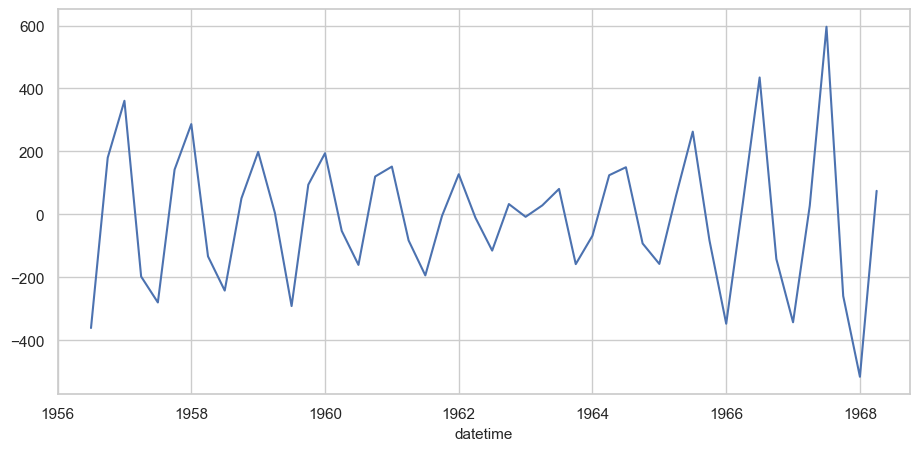

In [57]:
plt.figure(figsize=(11,5))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('datetime', fontsize=11)
decompose.resid.plot();

## 🧩 `decompose.resid.plot()` — what you’re looking at

### 🧠 What are “residuals” here?

After classical decomposition, your series is split into:

* **Trend** ➕ **Seasonal** ➕ **Remainder (residuals)**
  `decompose.resid` is that **remainder**: whatever is **left over** after removing trend and seasonality.

### 👀 What should the plot look like?

* **No obvious pattern**: residuals should “wiggle” around zero with **roughly constant spread**.
* **Short bursts** are okay, but **persistent waves** or **repeating cycles** mean trend/seasonality weren’t fully removed.
* **Outliers** will stick out as tall spikes — flag them.

### ✅ Good signs

* Residuals look like **white noise** (no visible structure).
* Mean ≈ 0; variance doesn’t grow/shrink over time.
* ACF of residuals has **no significant lags** (optional follow-up check).

### ⚠️ Red flags

* **Leftover seasonality** (e.g., repeating pattern every 4 quarters).
* **Drift** or a **slow wave** → trend not fully captured.
* **Heteroskedasticity** (spread changes over time) — maybe try a **log transform** before decomposing.


## 🧪 Stationarity check (ADF)  

In [32]:

fuller = adfuller(decompose.resid.dropna())
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.701448
p-value: 0.000000
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602


### 🧪 ADF results — interpretation

#### ✅ What this means (plain & simple)

* The **ADF statistic** is **−11.70**, which is **much more negative** than all the critical values (−3.59, −2.93, −2.60).
* The **p-value ≈ 0.000000** is effectively **zero**.
* 👉 We **reject the null** hypothesis of a unit root. The series, **as tested**, is **stationary**.



# ⚙️ Data transformation.  Make It Stationary (Diffs, Logs, Seasonality)

## 🗓️ Quarterly seasonality

Your electricity series is **quarterly**: Mar/Jun/Sep/Dec repeat every year. That means values **t** and **t−4** are in the **same quarter** a year apart.

### 🔧 Seasonal differencing (lag = 4)

`diff(4)` computes:
[
y_t - y_{t-4}
]
This **removes the recurring seasonal level** (the “same quarter last year” effect). After this step:

* Seasonal pattern is largely **canceled out** ✅
* The series becomes **more stationary** (flatter mean), making ACF/PACF easier to read ✅
* You’re preparing the data for **seasonal models** (e.g., SARIMA with period 4) ✅

### 🧹 `dropna()` cleanup

The first 4 values can’t compute `y_t - y_{t-4}`, so they become **NaN**.
`dropna()` simply **removes** those initial missing rows.

### 📌 When to use it

* For **quarterly** data with strong **yearly** seasonality → use `diff(4)`.
* For **monthly** data → you’d typically use `diff(12)`.
* Often you’ll then add a **first difference** too (e.g., `diff(4).diff()`) if a **trend** is still present.


In [34]:
au_elec_series_short_seas = dfs.diff(4).dropna()

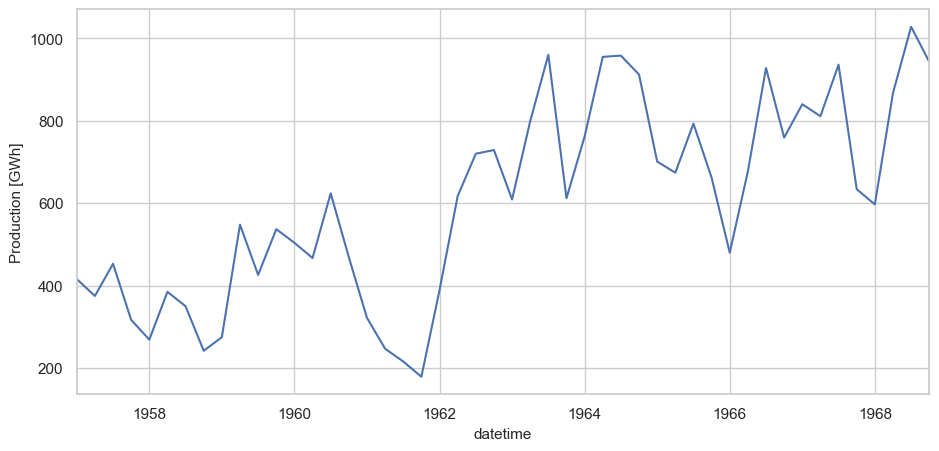

In [58]:
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Production [GWh]', fontsize=11)
plt.xlabel('datetime', fontsize=11)
au_elec_series_short_seas['electricity'].plot(figsize=(11,5));

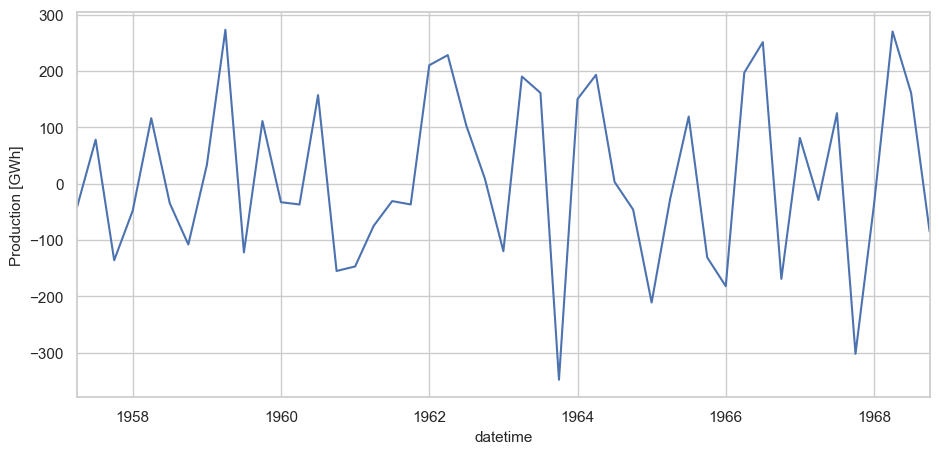

In [59]:
au_elec_series_short_diff = au_elec_series_short_seas.diff().dropna()

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Production [GWh]', fontsize=11)
plt.xlabel('datetime', fontsize=11)
au_elec_series_short_diff['electricity'].plot(figsize=(11,5));

## 🧪 Stationarity check (ADF)

### ✅ Plain takeaway

* The **ADF statistic** is **−7.22**, which is **far more negative** than all critical values (−3.59, −2.93, −2.60).
* The **p-value ≈ 0** ⇒ very strong evidence **against** the unit-root (non-stationary) null.
* **Conclusion:** the series (as tested) is **stationary**.

### 🧠 Why this matters

* You’ve transformed the data appropriately (e.g., seasonal and/or first differencing).
* It’s now suitable for ARMA/SARIMA modeling and for reading ACF/PACF patterns.

### 🔎 Next steps

* Use **ACF/PACF** to pick AR/MA orders (seasonal lags at 4, 8, … for quarterly).
* Check residuals after fitting (look for white-noise behavior).
* Optionally confirm with **KPSS** (should typically *not* reject stationarity now).


In [43]:
fuller = adfuller(au_elec_series_short_diff['electricity'])
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.215759
p-value: 0.000000
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602


## 🔎 Next steps

* Use **ACF/PACF** to pick AR/MA orders (seasonal lags at 4, 8, … for quarterly).
* Check residuals after fitting (look for white-noise behavior).
* Optionally confirm with **KPSS** (should typically *not* reject stationarity now).


# 📈 ACF — Autocorrelation Function

## 🤔 What is ACF?

The **Autocorrelation Function (ACF)** tells you how strongly a time series is related to **its own past values**.
For each **lag k**, ACF measures the correlation between (y_t) and (y_{t-k}).

Think: *“How similar is the series to itself if I shift it by k steps?”*

---

## 🧠 Why do we use it?

* **Detect persistence:** do values depend on recent past?
* **Spot seasonality:** big spikes at seasonal lags (e.g., 4 for quarterly, 12 for monthly).
* **Model selection (ARMA/SARIMA):** read ACF (with PACF) to guess AR and MA orders.

---

## 🔍 How to read the ACF plot

* **Significant spike at lag 1, then tailing off:** short-memory dependence; often suggests **MA(1)**-like behavior (but confirm with PACF).
* **Seasonal spikes** at (m, 2m, 3m,\dots): seasonality of period (m).
* **Slow decay** (very gradual fall) in the raw series: signals **non-stationarity** → consider differencing.

The vertical bars show correlation values; the shaded bands are **confidence intervals**. Bars **outside** the band ⇒ significant autocorrelation.

---

## 🧪 Stationarity tip before ACF

ACF is **most useful on a stationary series**. If the raw data has trend/seasonality:

1. **Seasonal difference** (e.g., `diff(4)` for quarterly).
2. **First difference** if trend remains.
3. Then plot ACF on the **differenced** series.



## 🧭 Interpreting common patterns

* **Strong lag-1 spike; quick drop:** short memory; try small **MA(q)**.
* **Spikes at lags 4, 8, 12…:** quarterly seasonality; include **seasonal MA** at period (m=4).
* **Many lags significant:** under-differenced or structural patterns still present → revisit transformations.

---

## ⚠️ Pitfalls & tips

* **Over-differencing** can create artificial negative lag-1 autocorrelation.
* **Outliers** can distort correlations — consider robust checks or winsorizing for diagnostics.
* **Short samples** make CIs wide; be cautious with small datasets.



## 🧩 ACF on raw data

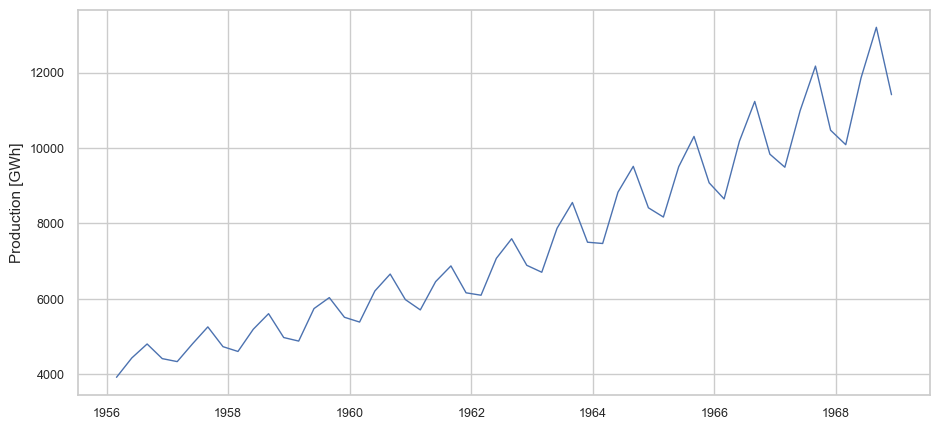

In [60]:
plt.figure(figsize=(11, 5))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.ylabel('Production [GWh]', fontsize=11)
plt.plot(dfs['electricity'], lw=1)
plt.show()

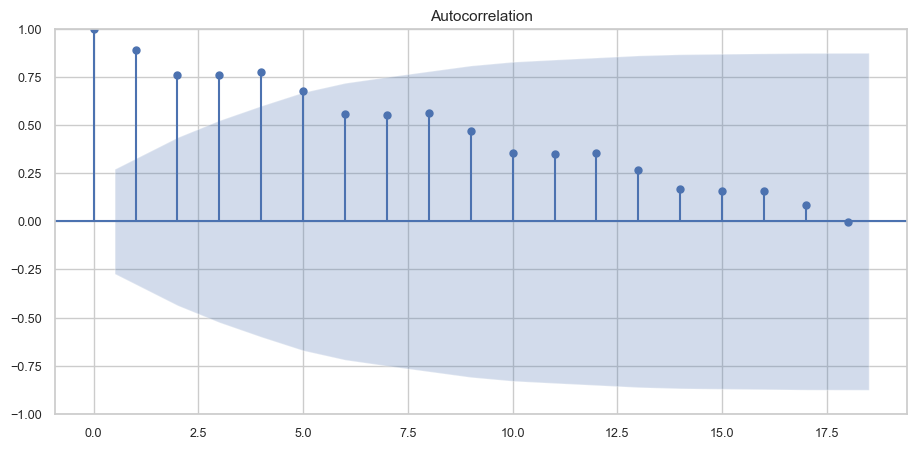

In [64]:
fig = plot_acf(dfs['electricity'])
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.title ('Autocorrelation', fontsize=11)
fig.set_size_inches((11, 5))

Here’s what that ACF says at a glance:

* **Strong persistence:** Lag-1 is ≈1, and the bars **decay slowly** over many lags.
* **Many positive lags are significant:** i.e., they stick above the confidence band early on.
* **No clear seasonal pattern:** you don’t see distinct extra-tall spikes at fixed intervals (e.g., 4, 8, 12 for quarterly). It’s mostly a **monotone decay**.

### Interpretation

* This is the classic look of a **non-stationary (trending) series**—a near-unit-root behavior.
* The slow tail suggests the level is drifting; the main issue is **trend**, not obvious seasonality (from this plot alone).


## 🧩 ACF on diff data

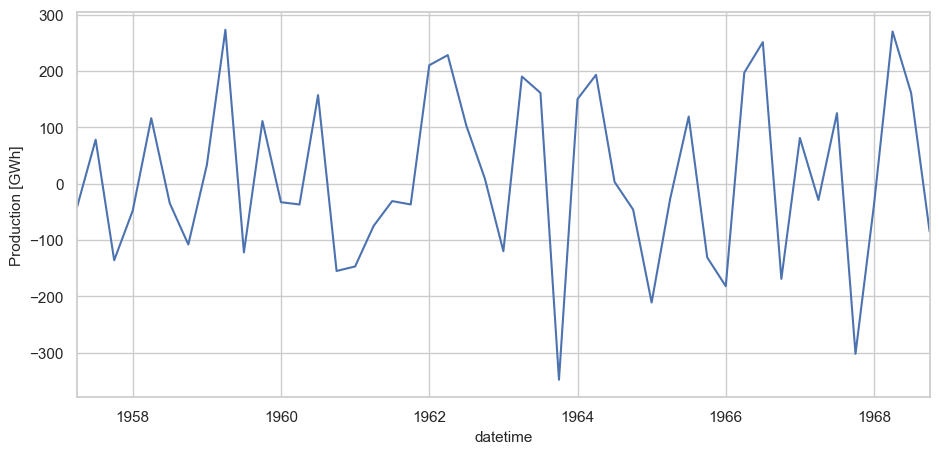

In [62]:
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Production [GWh]', fontsize=11)
plt.xlabel('datetime', fontsize=11)
au_elec_series_short_diff['electricity'].plot(figsize=(11,5));

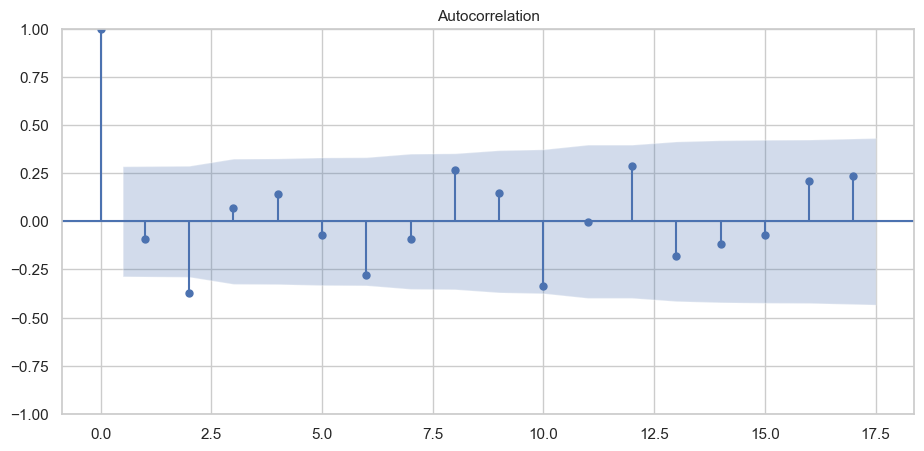

In [63]:
fig = plot_acf(au_elec_series_short_diff['electricity'])
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title ('Autocorrelation', fontsize=11)
fig.set_size_inches((11, 5))

Here’s how I’d read that ACF:

* **Stationary now:** aside from the spike at lag 0 (=1), the rest hover near zero with **no slow tail** → differencing did its job.
* **Seasonal fingerprints:** clear **positive spikes near lags 8, 12, 16** (multiples of 4) ⇒ **quarterly seasonality** remains in the autocorrelation structure.



# 📐 PACF — Partial Autocorrelation Function 

## 🤔 What is PACF?

The **Partial Autocorrelation Function (PACF)** measures the link between the series **now** and **k steps back**, **after removing** the effects of all the **intermediate lags** (1…k−1).
Think: *“What is the extra information from lag k once the nearer lags are already explained?”*

---

## 🧠 Why do we use it?

* **Choose AR order (p):** PACF is the go-to plot for spotting how many **autoregressive** lags you need.
* **See seasonal AR:** big spikes at seasonal lags (e.g., 4, 8, 12 for quarterly/monthly) hint at **seasonal AR** terms.

---

## 🔍 How to read the PACF plot

* **Cut-off pattern:** a few **early lags** are significant, then everything is inside the band → suggests **AR(p)** with p = number of significant early lags.
* **Single spike at lag 1** → **AR(1)**-like behavior.
* **Spikes at 4, 8, …** (for quarterly) → consider **seasonal AR(1)** with period 4.
* If you see a **slow tail** of many significant lags → likely **non-stationary**; difference first.

> The shaded band is the confidence interval. Bars **outside** it are “significant.”

---

## 🧪 Before you plot PACF

* Make the series **stationary** (difference, seasonal-difference, maybe log).
* PACF on non-stationary data can be misleading.

---

## 🧩 PACF vs ACF (cheat sheet)

* **PACF** helps pick **AR(p)** (partial correlations “cut off” after p).
* **ACF** helps pick **MA(q)** (autocorrelations “cut off” after q).
  Use **both** to propose (p, q), then confirm with AIC/BIC and residual checks.


---

## 🧭 Interpreting common patterns

* **PACF: big spike at lag 1 only** → try **AR(1)**.
* **PACF: spikes at 1 & 2** → try **AR(2)**.
* **PACF: spike at 4** (quarterly) → **seasonal AR(1)** with m=4.
* **Many significant lags** → recheck **stationarity** or consider more complex structure.

---


## 🧩 ACF vs PACF (quick cheat sheet)

* **ACF** highlights **MA** structure (cut-off at q) and **seasonal MA** (spikes at seasonal lags).
* **PACF** highlights **AR** structure (cut-off at p) and **seasonal AR**.

*Rule of thumb (not strict):*

* ACF cuts off at lag **q** (after difference) ⇒ consider **MA(q)**.
* PACF cuts off at lag **p** ⇒ consider **AR(p)**.


## 🎯 Takeaway

Use **ACF** (with **PACF**) on a **stationary** version of your series to:

1. confirm seasonality and persistence, and
2. pick reasonable **AR/MA** orders for (S)ARIMA before fine-tuning with information criteria and residual checks.


## 🧩 PACF on raw data

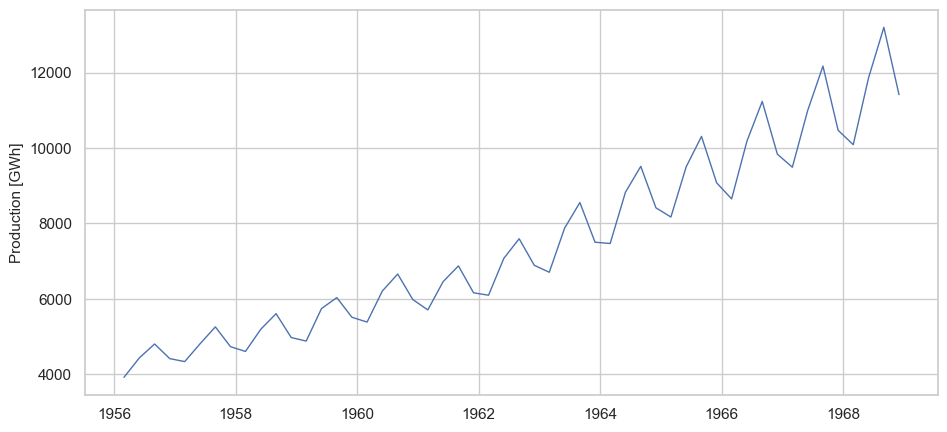

In [65]:
plt.figure(figsize=(11, 5))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Production [GWh]', fontsize=11)
plt.plot(dfs['electricity'], lw=1)
plt.show()

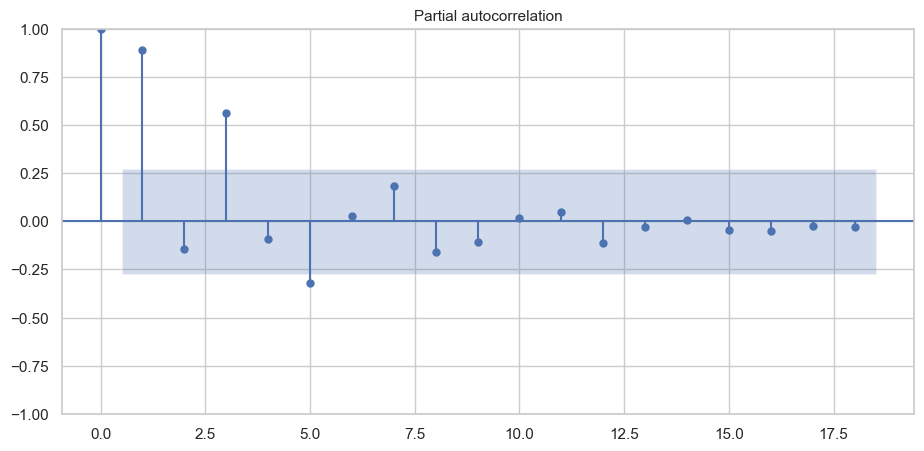

In [66]:
fig = plot_pacf(dfs['electricity'])
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Partial autocorrelation', fontsize=11)
fig.set_size_inches((11, 5))

Here’s how I’d read that PACF:

* **Big spikes at lags 1 and 2** ➜ strong **AR(1–2)** behavior in the non-seasonal part (the “partial” correlations die off after lag 2).
* **Clear spike at lag 4** ➜ **seasonal AR(1)** at the quarterly period (m=4).
* **Other lags sit inside the band** ➜ no strong higher-order AR terms; the series looks **stationary** (you likely already differenced appropriately).


## 🧩 PACF on diff data

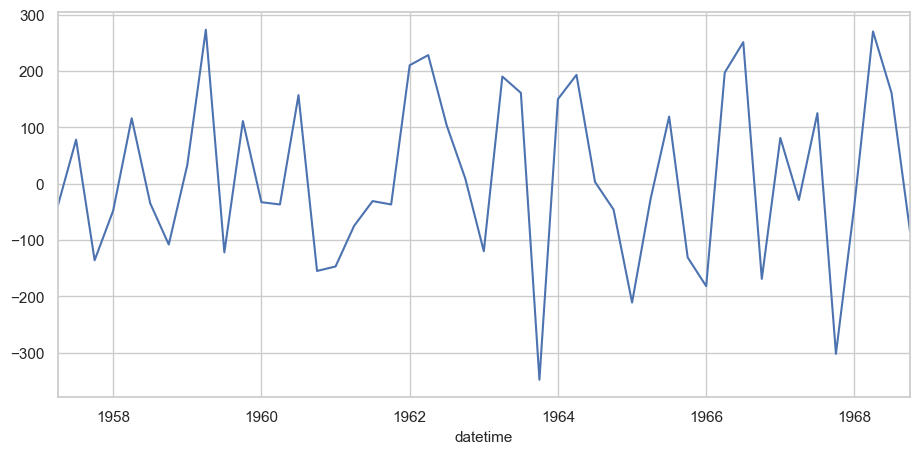

In [67]:
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('datetime', fontsize=11)
au_elec_series_short_diff['electricity'].plot(figsize=(11,5));

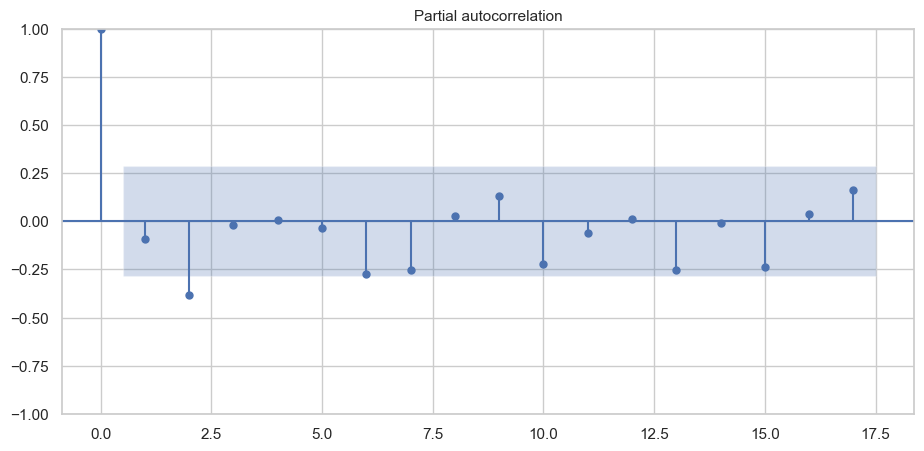

In [68]:
fig = plot_pacf(au_elec_series_short_diff['electricity'])
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Partial autocorrelation', fontsize=11)
fig.set_size_inches((11, 5))

* **No clear cut-off after a few small lags.** Most bars (lags 1–18) sit **inside the confidence band**.
* There’s a **modest negative dip around lag 2** and a few tiny bumps later, but nothing strongly significant.
* **No distinct seasonal AR spike** at a fixed seasonal lag (e.g., 4, 8, 12, 16 for quarterly).

# 📈 AR / ARIMA — intuition + quick practice

## 🤔 Big picture

* **AR(p)** — *AutoRegressive*: today depends on **p** past values
  ( y_t = \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t )
* **I(d)** — *Integrated*: **d** differences to remove trend/drift
  ( \nabla^d y_t ) is the stationary series you actually model
* **MA(q)** — *Moving Average*: today depends on **q** past **errors**
  ( y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q} )

> Intuition:
>
> * AR = “momentum/memory in levels”
> * I = “stabilize first, then model”
> * MA = “soak up shock patterns in errors”

https://www.alldatascience.com/time-series/forecasting-time-series-with-arima/

https://analyticsindiamag.com/topics/sarimax-in-python-for-time-series-modeling/

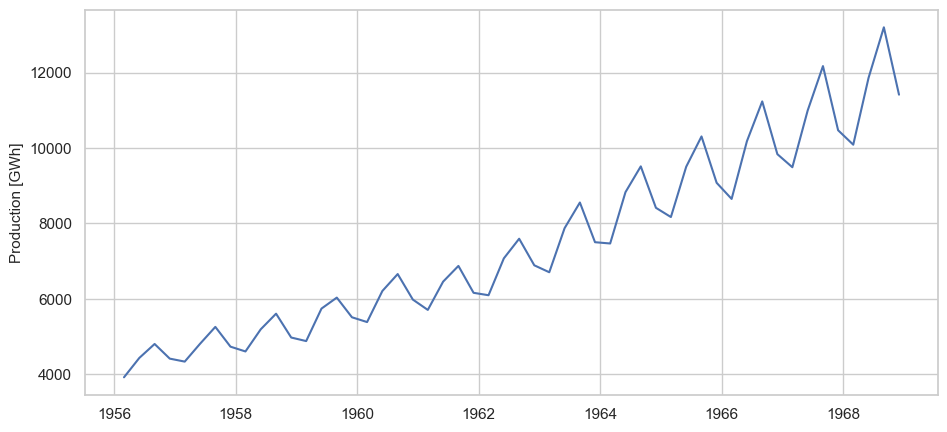

In [70]:
plt.figure(figsize=(11, 5))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.plot(dfs['electricity'])
plt.ylabel('Production [GWh]', fontsize=11)
plt.show()

## 🧪 Stationarity check (ADF)  

In [71]:
fuller = adfuller(dfs['electricity'])
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 2.233387
p-value: 0.998909
Critical Values:
	1%: -3.578
	5%: -2.925
	10%: -2.601


## 🧩 Decomposition + model

### Why decompose first?

Decomposition shows **what the model must explain**:

* **Trend** ➜ use **differencing** (I(d)=1 if trend exists).
* **Seasonality (period = 4)** ➜ add **seasonal terms** (SARIMA with `m=4`).
* **Remainder** ➜ should look like **noise** after modeling.

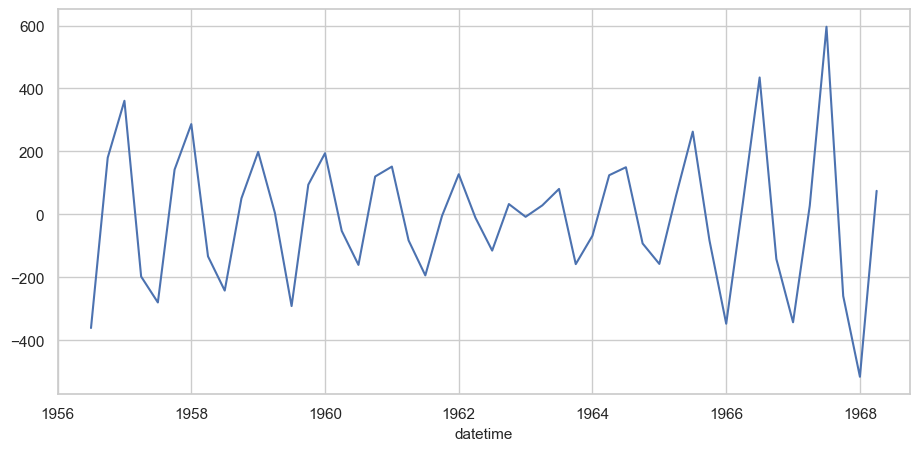

In [73]:
plt.figure(figsize=(11,5))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('datetime', fontsize=11)
decompose.resid.plot();

### Stationarity check (ADF) 🧪  


In [74]:
fuller = adfuller(decompose.resid.dropna())
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.701448
p-value: 0.000000
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602


In [75]:
res = pd.DataFrame(decompose.resid.dropna())

In [77]:
import pmdarima as pm
auto_arima = pm.auto_arima(res['resid'], stepwise=False, seasonal=False)
auto_arima

ARIMA(order=(5, 0, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

### 🧮 ARIMA fit


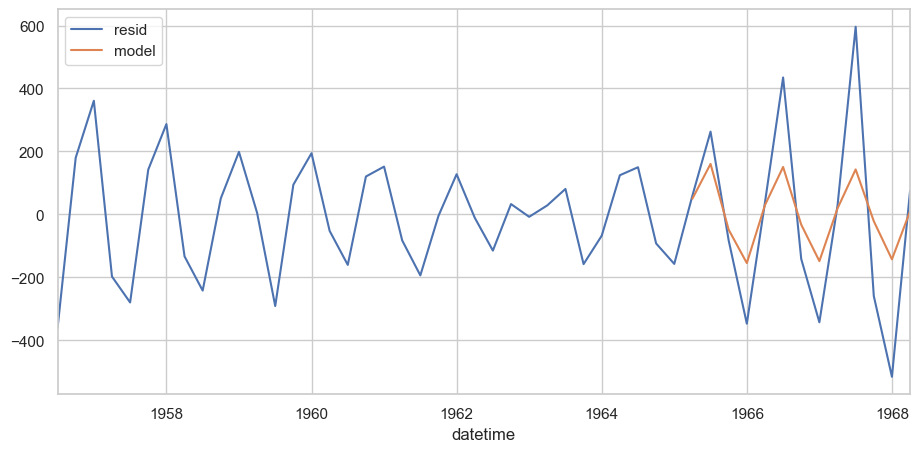

In [79]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(res['resid'],order=(5,0,0))
history = model.fit()

res['model'] = history.predict(start=35,end=80,dynamic=True)
res[['resid','model']].plot(figsize=(11,5));

In [80]:
print(history.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                   48
Model:                 ARIMA(5, 0, 0)   Log Likelihood                -272.051
Date:                Mon, 27 Oct 2025   AIC                            558.101
Time:                        13:56:46   BIC                            571.200
Sample:                    09-01-1956   HQIC                           563.051
                         - 06-01-1968                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4039      2.441     -0.985      0.325      -7.188       2.380
ar.L1         -0.6018      0.154     -3.920      0.000      -0.903      -0.301
ar.L2         -1.1337      0.188     -6.038      0.0

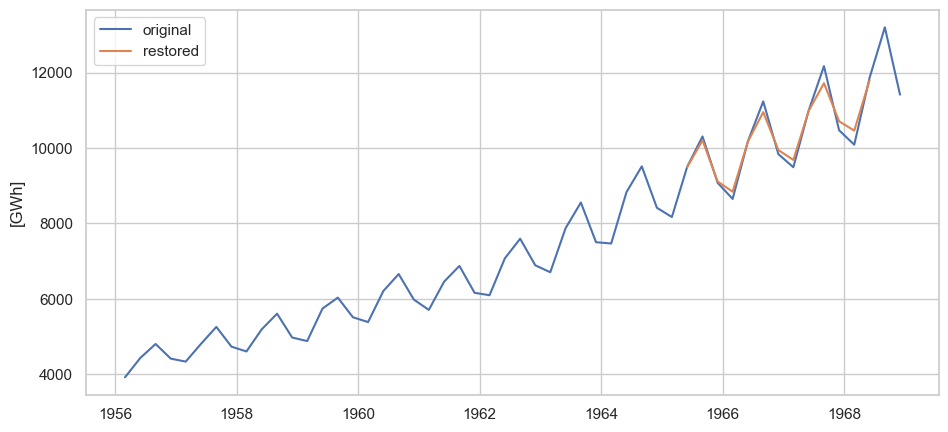

In [81]:
plt.figure(figsize=(11,5))
plt.plot(dfs['electricity'], label="original")
plt.plot(res['model'] + decompose.trend + decompose.seasonal, label="restored")
plt.ylabel('[GWh]')
plt.legend(loc="upper left")
plt.show()

## 🧩 Transformation + model

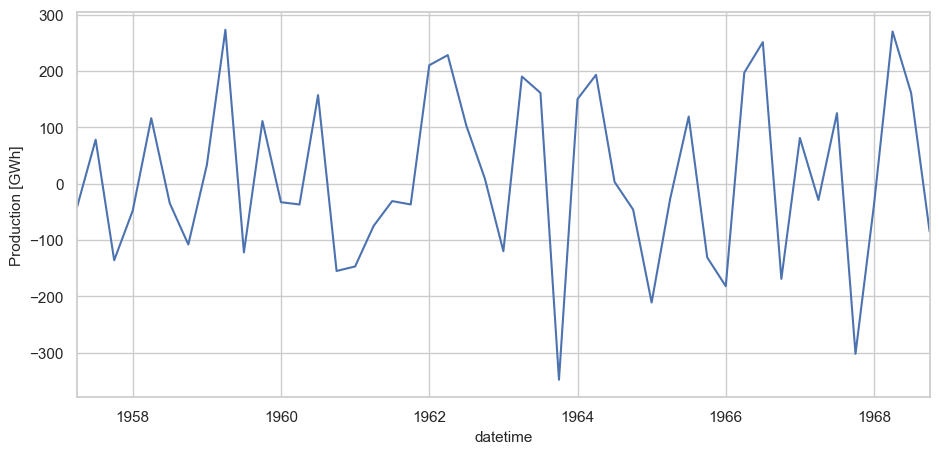

In [82]:
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Production [GWh]', fontsize=11)
plt.xlabel('datetime', fontsize=11)
au_elec_series_short_diff['electricity'].plot(figsize=(11,5));

### 🧪Stationarity check (ADF) 


In [83]:
fuller = adfuller(au_elec_series_short_diff['electricity'])
print('ADF Statistic: %f' % fuller[0])
print('p-value: %f' % fuller[1])
print('Critical Values:')
for key, value in fuller[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.215759
p-value: 0.000000
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602


### 🔍 ACF 


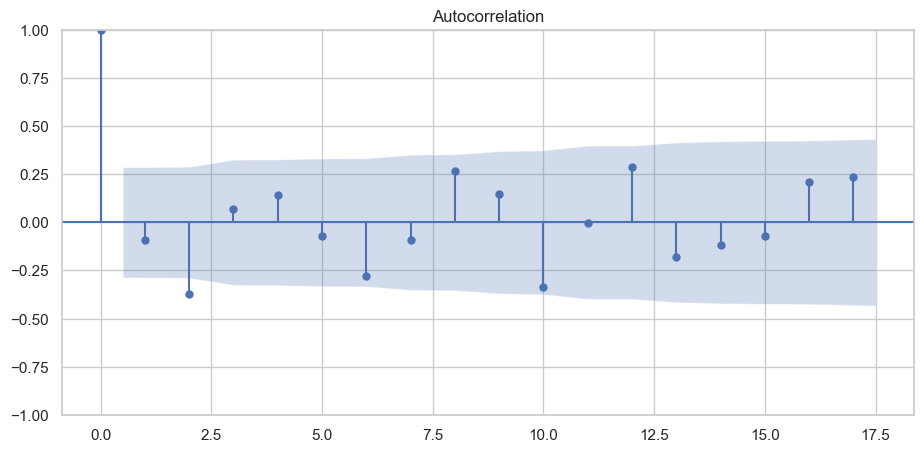

In [87]:
acf_plot = plot_acf(au_elec_series_short_diff['electricity'])
acf_plot.set_size_inches((11, 5))

# MA =2

### 🔍 PACF 

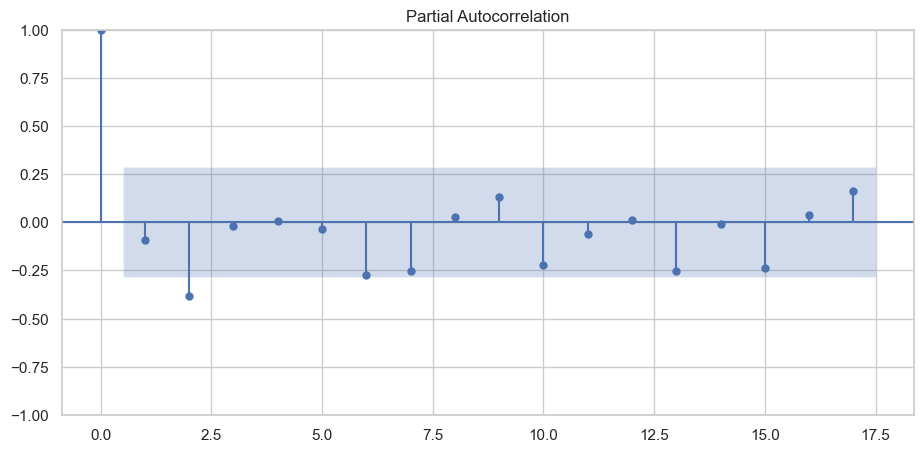

In [86]:
pacf_plot = plot_pacf(au_elec_series_short_diff['electricity'])
pacf_plot.set_size_inches((11, 5))

# AR = 2

In [88]:
train_end = datetime.datetime(1968,3,1)
test_start = datetime.datetime(1968,6,1)
test_end = datetime.datetime(1968,12,1)

train_data = au_elec_series_short_diff[:train_end]
test_data = au_elec_series_short_diff[test_start:test_end]

In [89]:
import pmdarima as pm
auto_arima = pm.auto_arima(train_data, stepwise=False, seasonal=False)
auto_arima

ARIMA(order=(2, 0, 2), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

###  🧮 ARIMA fit 


In [90]:
from statsmodels.tsa.arima.model import ARIMA

# define the model
model = ARIMA(train_data, order=(2,0,2))

# fit the model
model_fit = model.fit()

# summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            electricity   No. Observations:                   44
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -277.270
Date:                Mon, 27 Oct 2025   AIC                            566.539
Time:                        13:59:39   BIC                            577.244
Sample:                    06-01-1957   HQIC                           570.509
                         - 03-01-1968                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6923     18.744      0.250      0.802     -32.044      41.429
ar.L1          0.0975      0.217      0.449      0.653      -0.328       0.523
ar.L2         -0.9488      0.144     -6.567      0.0

In [91]:
# get prediction start and end dates: training data
pred_start_date = train_data.index[0]
pred_end_date = train_data.index[-1]

In [92]:
validations = model_fit.predict(start=pred_start_date, end=pred_end_date)


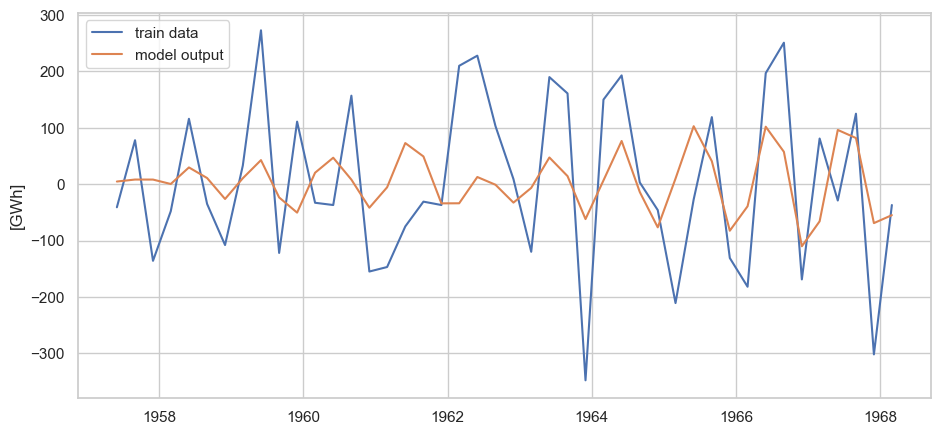

In [93]:
plt.figure(figsize=(11,5))
plt.plot(train_data, label="train data")
plt.plot(validations, label="model output")
plt.ylabel('[GWh]')
plt.legend(loc="upper left")
plt.show()

### Residuals

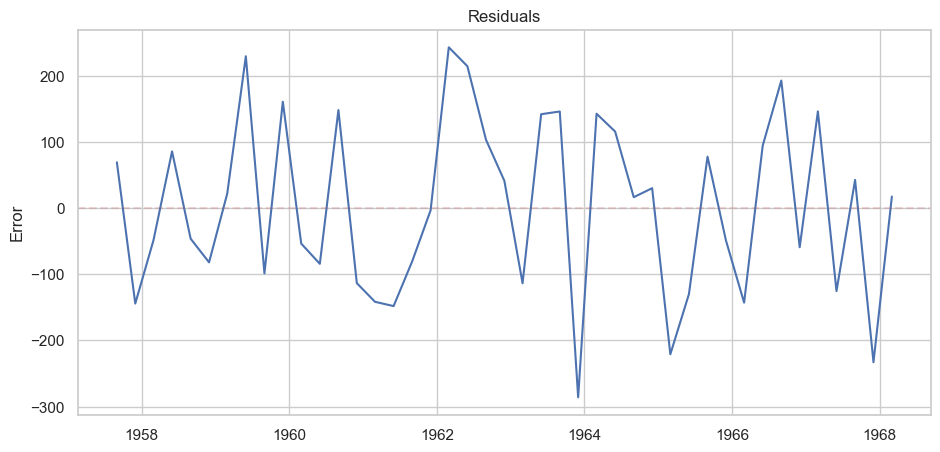

In [94]:
fig_res = plt.figure(figsize=(11,5))
residuals = model_fit.resid[1:]
plt.plot(residuals)
plt.axhline(0, color='r', linestyle='--', alpha=0.2)
plt.title('Residuals')
plt.ylabel('Error')
plt.show()

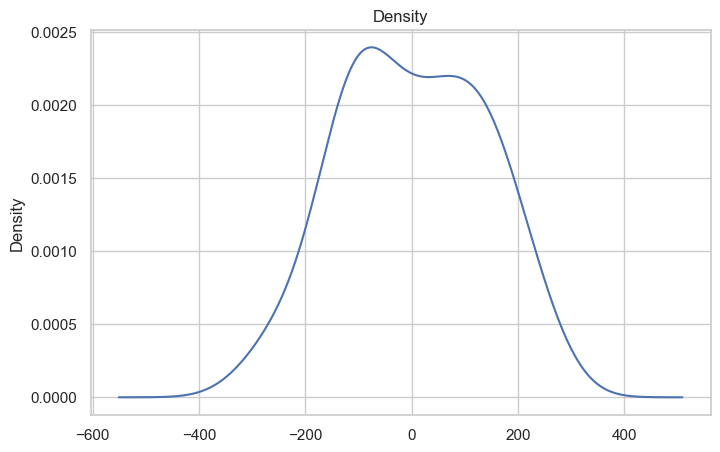

In [95]:
fig_dens_res = plt.figure(figsize=(8,5))
residuals.plot(title='Density', kind='kde')
plt.show()

#### ACF (residuals)

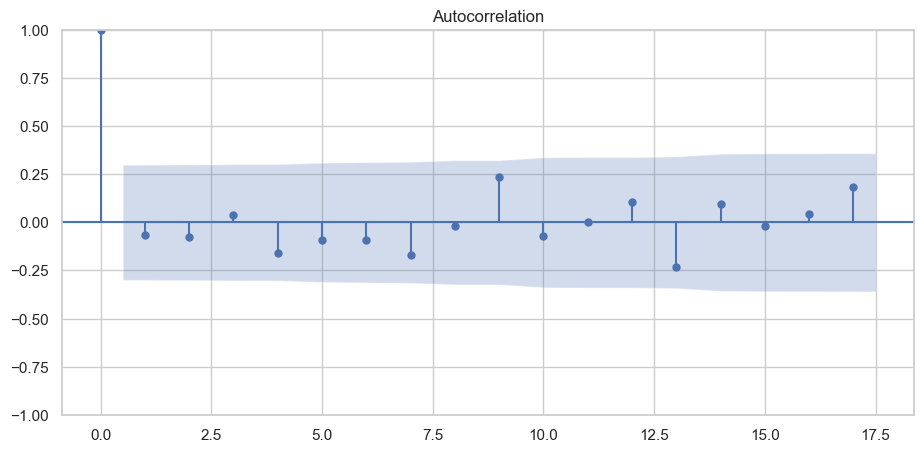

In [97]:
fig_acf_resid = plot_acf(residuals)
fig_acf_resid.set_size_inches((11, 5))

#### PACF (residuals)

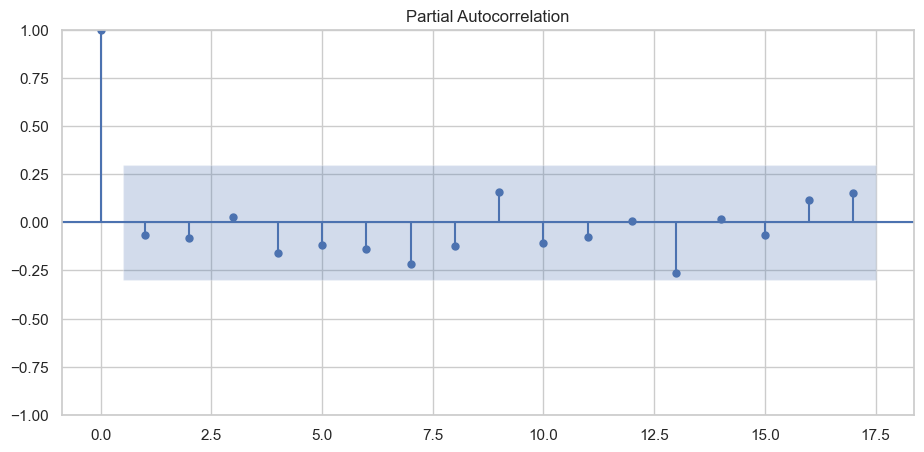

In [98]:
fig_pacf_resid = plot_pacf(residuals)
fig_pacf_resid.set_size_inches((11, 5))

### 🔢  Restore
#### CUMSUM — cumulative sum (tutorial style)

**What it is:**
**CUMSUM** (a.k.a. `cumsum`) is the running total of a series.
For values $(x_1, x_2, \dots, x_t)$, the cumulative sum is

$\text{cumsum}_t=\sum_{i=1}^{t} x_i$


In [99]:
a = np.array([10, 11, 12, 13, 14, 15])

In [100]:
np.cumsum(a)

array([10, 21, 33, 46, 60, 75])

In [101]:
def integrate(values):
    x = np.cumsum(values)
    return x


In [102]:
def differentiate(values):  
    x = np.concatenate([[values[0]], values[1:]-values[:-1]])
    return x

In [103]:
dd = differentiate(a)
dd

array([10,  1,  1,  1,  1,  1])

In [104]:
i = integrate(dd)
i

array([10, 11, 12, 13, 14, 15])

#### Restore data

In [105]:
validations_df = pd.DataFrame(data=validations)
validations_df_rnm = validations_df.rename(columns={"predicted_mean": "electricity"})

In [106]:
valid_mrg = pd.concat([au_elec_series_short_seas.iloc[[0]], 
                       validations_df_rnm], ignore_index = False)

In [107]:
valid_mrg_cums = valid_mrg.cumsum()

In [108]:
valid_mrg_cums_mrg = pd.concat([dfs.iloc[0:4], 
                                valid_mrg_cums], ignore_index = False)

In [109]:
dfQ1sl = valid_mrg_cums_mrg[::4]
dfQ2sl = valid_mrg_cums_mrg[1::4]
dfQ3sl = valid_mrg_cums_mrg[2::4]
dfQ4sl = valid_mrg_cums_mrg[3::4]

dfQ1slCUM = dfQ1sl.cumsum()
dfQ2slCUM = dfQ2sl.cumsum()
dfQ3slCUM = dfQ3sl.cumsum()
dfQ4slCUM = dfQ4sl.cumsum()

In [110]:
dfCUMf = pd.concat([dfQ1slCUM, dfQ2slCUM, dfQ3slCUM, dfQ4slCUM], ignore_index = False)
dfCUMfsorted = dfCUMf.sort_index()

In [111]:
audropped = dfs.drop(index=['1968-06-01','1968-09-01','1968-12-01'])

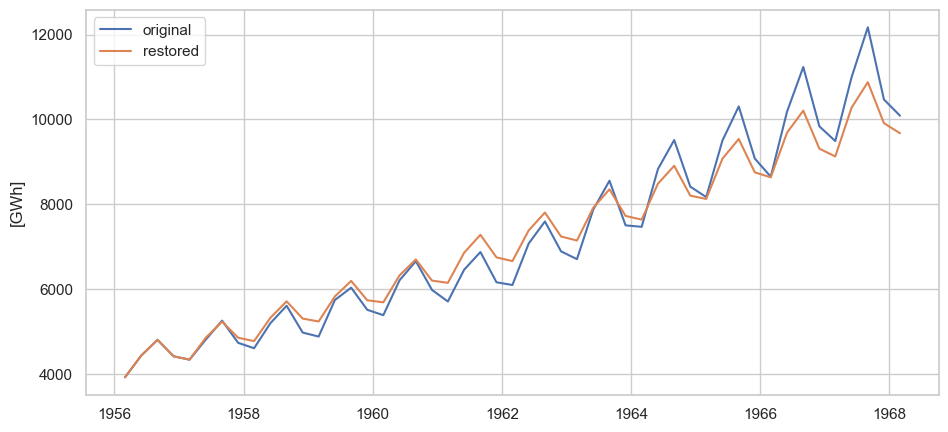

In [112]:
plt.figure(figsize=(11,5))
plt.plot(audropped, label="original")
plt.plot(dfCUMfsorted, label="restored")
plt.ylabel('[GWh]')
plt.legend(loc="upper left")
plt.show()


# 📅 Seasonal ARIMA (SARIMA) 
> **Goal:** model time series with **trend + seasonality** using SARIMA.
> **When to use:** quarterly, monthly, weekly data with repeating patterns (e.g., electricity demand, sales).

---

## 🧩 What is SARIMA?

SARIMA adds **seasonal AR/MA and seasonal differencing** to ARIMA.

**Notation:**
$\text{SARIMA}(p,d,q),(P,D,Q)_m$

* **Non-seasonal:** (p)=AR lags, (d)=differences, (q)=MA lags
* **Seasonal:** (P)=seasonal AR lags, (D)=seasonal differences, (Q)=seasonal MA lags
* **m** = seasonal period (e.g., **4** = quarters, **12** = months)

**Intuition:**

* **I(d)** removes **trend**
* **I_m(D)** removes **seasonal mean shifts**
* **AR / MA** terms capture **short-memory** patterns in the differenced data
* **Seasonal AR / MA** terms capture **lag-m** relationships (same season last cycle)

---


In [113]:
model = sm.tsa.statespace.SARIMAX(dfs['electricity'],order=(2, 1, 2),seasonal_order=(1,1,1,4))
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.18954D+00    |proj g|=  9.46568D-01

At iterate    5    f=  5.73021D+00    |proj g|=  2.59464D-02

At iterate   10    f=  5.72525D+00    |proj g|=  5.39365D-02

At iterate   15    f=  5.71142D+00    |proj g|=  2.25968D-02

At iterate   20    f=  5.69735D+00    |proj g|=  2.05842D-02

At iterate   25    f=  5.68512D+00    |proj g|=  1.91411D-03

At iterate   30    f=  5.67350D+00    |proj g|=  1.52528D-02

At iterate   35    f=  5.66956D+00    |proj g|=  2.65689D-03

At iterate   40    f=  5.66938D+00    |proj g|=  4.39695D-04

At iterate   45    f=  5.66403D+00    |proj g|=  2.51109D-02

At iterate   50    f=  5.65896D+00    |proj g|=  1.87874D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

 This problem is unconstrained.


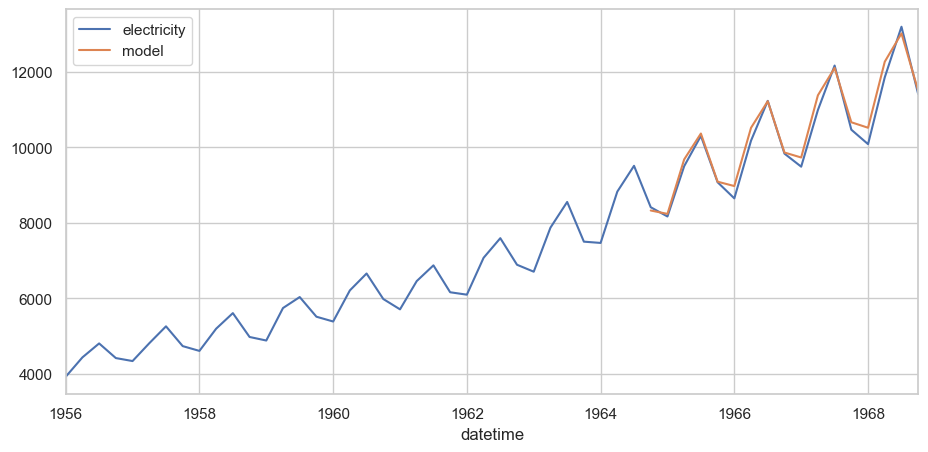

In [114]:
dfs['model'] = results.predict(start=35,end=60,dynamic=True)
dfs[['electricity','model']].plot(figsize=(11,5));